# Install Libraries

In [4]:
%pip install gymnasium numpy matplotlib torch pygame

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ------------------- -------------------- 5.2/10.6 MB 53.0 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 33.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# CartPole — Deep Q-Network (DQN) from Scratch

## The Game
A pole is attached by a hinge to a cart that moves along a frictionless track. The agent must push the cart left or right to keep the pole balanced upright.

- **Episode ends** when the pole tilts > 12°, the cart leaves the track, or 500 steps are reached.
- **Goal**: survive as long as possible (max reward per episode = 500).

## RL Formulation
- **State**: 4 continuous values — cart position, cart velocity, pole angle, pole angular velocity
- **Action**: 0=push left, 1=push right
- **Reward**: +1 for every step the pole stays upright

## Why DQN Instead of Tabular?
The state is continuous — we can't enumerate all positions in a table. Instead we train a neural network to approximate `Q(s, a)` for any state `s`.

## Key DQN Components
| Component | Purpose |
|---|---|
| **Q-Network** (online) | Maps state → Q-values for each action |
| **Target Network** | Frozen copy, updated periodically — stabilises training |
| **Replay Buffer** | Stores past transitions; breaks temporal correlations |
| **Epsilon-Greedy** | Balances exploration vs exploitation |

# Create & Test Environment

In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

def test_env(env, num_steps=50):
    obs, _ = env.reset()
    total_reward = 0
    for step in range(num_steps):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        if terminated or truncated:
            print(f'Episode ended at step {step+1}, total reward: {total_reward}')
            break
    env.close()

env = gym.make('CartPole-v1')
print('Observation space:', env.observation_space)
print('Action space:', env.action_space)
test_env(env)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Episode ended at step 18, total reward: 18.0


# Define DQN Components

In [6]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

env = gym.make('CartPole-v1')
obs_dim  = env.observation_space.shape[0]  # 4
n_actions = env.action_space.n             # 2

online_net = QNetwork(obs_dim, n_actions).to(device)
target_net = QNetwork(obs_dim, n_actions).to(device)
target_net.load_state_dict(online_net.state_dict())
target_net.eval()

print(online_net)

Device: cpu
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


# Train Agent

In [10]:
import os

# Hyperparameters
N_EPISODES      = 500
BUFFER_SIZE     = 10_000
BATCH_SIZE      = 64
GAMMA           = 0.99
LR              = 1e-3
EPSILON_START   = 1.0
EPSILON_END     = 0.02
EPSILON_DECAY   = 500
TARGET_UPDATE   = 10
WARMUP_EPISODES = 10

# Save checkpoints at 0%, 25%, 50%, 75%, 100%
CHECKPOINT_EPISODES = [0, N_EPISODES // 4, N_EPISODES // 2, 3 * N_EPISODES // 4, N_EPISODES - 1]
CHECKPOINT_LABELS   = ['Untrained (ep 0)', '25% (ep 125)', '50% (ep 250)', '75% (ep 375)', '100% (ep 500)']
os.makedirs('models/cartpole', exist_ok=True)

# Re-initialise networks fresh for reproducible training
online_net = QNetwork(obs_dim, n_actions).to(device)
target_net = QNetwork(obs_dim, n_actions).to(device)
target_net.load_state_dict(online_net.state_dict())
target_net.eval()

buffer    = ReplayBuffer(BUFFER_SIZE)
optimizer = optim.Adam(online_net.parameters(), lr=LR)
loss_fn   = nn.MSELoss()
episode_rewards = []

for episode in range(N_EPISODES):
    if episode in CHECKPOINT_EPISODES:
        idx = CHECKPOINT_EPISODES.index(episode)
        path = f'models/cartpole/dqn_ep{episode}.pt'
        torch.save(online_net.state_dict(), path)
        print(f'Saved checkpoint [{CHECKPOINT_LABELS[idx]}] -> {path}')

    state, _ = env.reset()
    total_reward = 0
    epsilon = EPSILON_END + (EPSILON_START - EPSILON_END) * max(0, 1 - episode / EPSILON_DECAY)

    while True:
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action = online_net(s).argmax(dim=1).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(state, action, reward, next_state, float(done))
        state = next_state
        total_reward += reward

        if len(buffer) >= BATCH_SIZE and episode >= WARMUP_EPISODES:
            states_b, actions_b, rewards_b, next_states_b, dones_b = buffer.sample(BATCH_SIZE)
            s  = torch.tensor(states_b,      device=device)
            a  = torch.tensor(actions_b,     device=device)
            r  = torch.tensor(rewards_b,     device=device)
            ns = torch.tensor(next_states_b, device=device)
            d  = torch.tensor(dones_b,       device=device)

            q_values = online_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                next_q = target_net(ns).max(1).values
                targets = r + GAMMA * next_q * (1 - d)

            loss = loss_fn(q_values, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    episode_rewards.append(total_reward)

    if (episode + 1) % TARGET_UPDATE == 0:
        target_net.load_state_dict(online_net.state_dict())

    if (episode + 1) % 50 == 0:
        avg = np.mean(episode_rewards[-50:])
        print(f'Episode {episode+1:4d} | ε={epsilon:.3f} | avg reward (last 50): {avg:.1f}')

# Save final checkpoint
torch.save(online_net.state_dict(), f'models/cartpole/dqn_ep{N_EPISODES-1}.pt')
env.close()

Saved checkpoint [Untrained (ep 0)] -> models/cartpole/dqn_ep0.pt
Episode   50 | ε=0.904 | avg reward (last 50): 19.0
Episode  100 | ε=0.806 | avg reward (last 50): 27.0
Saved checkpoint [25% (ep 125)] -> models/cartpole/dqn_ep125.pt
Episode  150 | ε=0.708 | avg reward (last 50): 38.6
Episode  200 | ε=0.610 | avg reward (last 50): 55.4
Episode  250 | ε=0.512 | avg reward (last 50): 52.4
Saved checkpoint [50% (ep 250)] -> models/cartpole/dqn_ep250.pt
Episode  300 | ε=0.414 | avg reward (last 50): 65.0
Episode  350 | ε=0.316 | avg reward (last 50): 73.2
Saved checkpoint [75% (ep 375)] -> models/cartpole/dqn_ep375.pt
Episode  400 | ε=0.218 | avg reward (last 50): 154.4
Episode  450 | ε=0.120 | avg reward (last 50): 194.1
Saved checkpoint [100% (ep 500)] -> models/cartpole/dqn_ep499.pt
Episode  500 | ε=0.022 | avg reward (last 50): 209.7


# Evaluate & Visualize

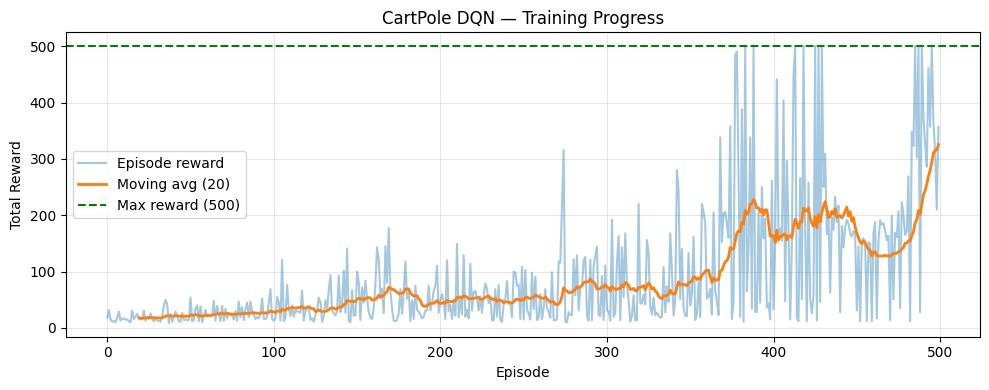

In [11]:
window = 20
moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.4, label='Episode reward')
plt.plot(range(window-1, len(episode_rewards)), moving_avg, label=f'Moving avg ({window})', linewidth=2)
plt.axhline(500, color='green', linestyle='--', label='Max reward (500)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('CartPole DQN — Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Greedy policy: avg=142.5, min=137.0, max=151.0


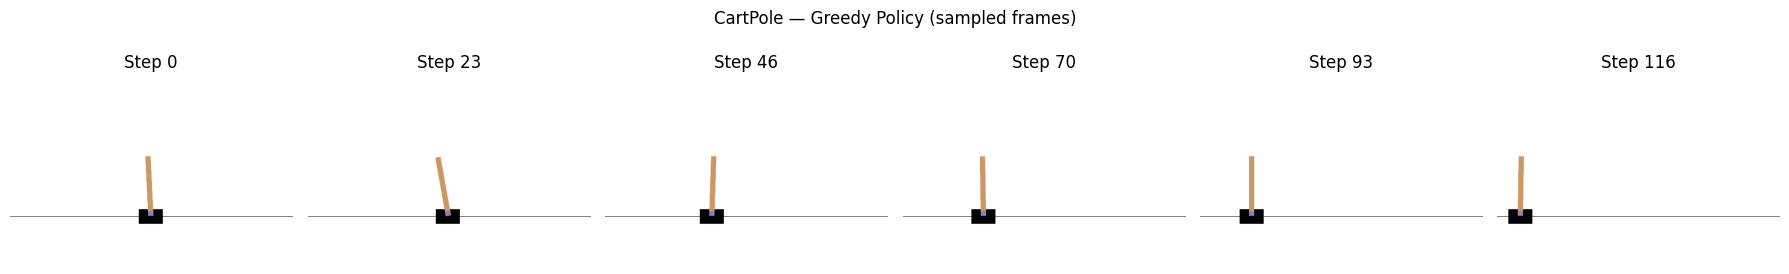

In [12]:
# Run greedy policy and record frames
env_eval = gym.make('CartPole-v1', render_mode='rgb_array')
online_net.eval()

N_EVAL = 10
eval_rewards = []
frames = []

for ep in range(N_EVAL):
    state, _ = env_eval.reset()
    total = 0
    ep_frames = []
    while True:
        if ep == 0:  # record first episode only
            ep_frames.append(env_eval.render())
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            action = online_net(s).argmax(dim=1).item()
        state, reward, terminated, truncated, _ = env_eval.step(action)
        total += reward
        if terminated or truncated:
            break
    eval_rewards.append(total)
    if ep == 0:
        frames = ep_frames

env_eval.close()
print(f'Greedy policy: avg={np.mean(eval_rewards):.1f}, min={min(eval_rewards)}, max={max(eval_rewards)}')

# Display first few frames
n_show = min(6, len(frames))
fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3))
for i, ax in enumerate(axes):
    idx = int(i * len(frames) / n_show)
    ax.imshow(frames[idx])
    ax.set_title(f'Step {idx}')
    ax.axis('off')
plt.suptitle('CartPole — Greedy Policy (sampled frames)')
plt.tight_layout()
plt.show()

# Compare: Untrained vs Intermediate vs Fully Trained

Load each saved checkpoint and run 20 greedy evaluation episodes. We compare reward distributions and show a mid-episode frame from each stage.

In [13]:
def eval_checkpoint(path, n_episodes=20):
    net = QNetwork(obs_dim, n_actions).to(device)
    net.load_state_dict(torch.load(path, map_location=device))
    net.eval()
    env_eval = gym.make('CartPole-v1', render_mode='rgb_array')
    rewards, frames = [], []
    for ep in range(n_episodes):
        state, _ = env_eval.reset()
        total, ep_frames = 0, []
        while True:
            if ep == 0:
                ep_frames.append(env_eval.render())
            with torch.no_grad():
                s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action = net(s).argmax(dim=1).item()
            state, reward, terminated, truncated, _ = env_eval.step(action)
            total += reward
            if terminated or truncated:
                break
        rewards.append(total)
        if ep == 0:
            frames = ep_frames
    env_eval.close()
    return rewards, frames

checkpoint_paths = [f'models/cartpole/dqn_ep{ep}.pt' for ep in CHECKPOINT_EPISODES]
all_rewards, all_frames_list = [], []

print(f'{"Checkpoint":28s}  Mean    Min   Max')
print('-' * 52)
for path, label in zip(checkpoint_paths, CHECKPOINT_LABELS):
    rewards, frames = eval_checkpoint(path)
    all_rewards.append(rewards)
    all_frames_list.append(frames)
    print(f'{label:28s}  {np.mean(rewards):5.1f}  {min(rewards):5.0f}  {max(rewards):5.0f}')

Checkpoint                    Mean    Min   Max
----------------------------------------------------
Untrained (ep 0)              216.9     42    500
25% (ep 125)                  169.8    123    241
50% (ep 250)                  111.0    103    135
75% (ep 375)                  349.8    203    500
100% (ep 500)                 143.8    134    159


C:\Users\danal\AppData\Local\Temp\ipykernel_14552\4073732522.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(all_rewards, labels=CHECKPOINT_LABELS, patch_artist=True)


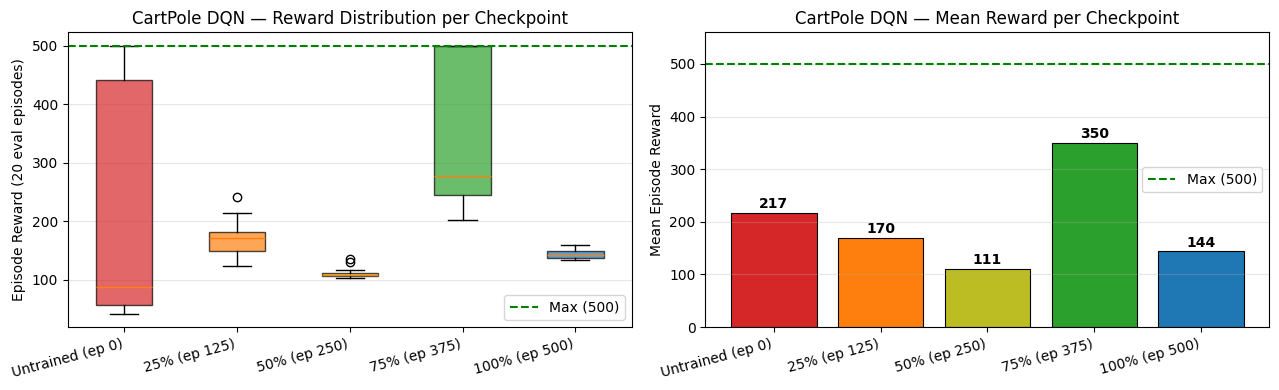

In [14]:
colors_ck = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot — reward distribution
ax = axes[0]
bp = ax.boxplot(all_rewards, labels=CHECKPOINT_LABELS, patch_artist=True)
for patch, c in zip(bp['boxes'], colors_ck):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.axhline(500, color='green', linestyle='--', label='Max (500)')
ax.set_ylabel('Episode Reward (20 eval episodes)')
ax.set_title('CartPole DQN — Reward Distribution per Checkpoint')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

# Mean reward bar chart
ax2 = axes[1]
means = [np.mean(r) for r in all_rewards]
bars = ax2.bar(CHECKPOINT_LABELS, means, color=colors_ck, edgecolor='black', linewidth=0.8)
for bar, m in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{m:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(500, color='green', linestyle='--', label='Max (500)')
ax2.set_ylim(0, 560)
ax2.set_ylabel('Mean Episode Reward')
ax2.set_title('CartPole DQN — Mean Reward per Checkpoint')
ax2.legend(); ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

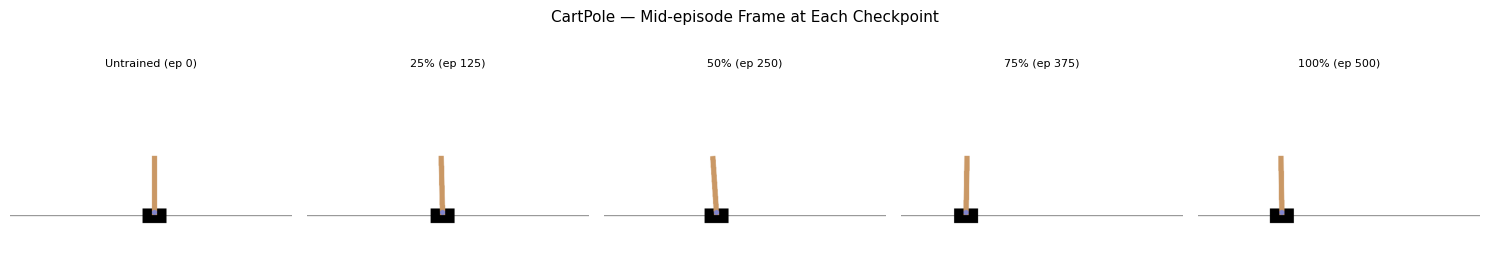

In [15]:
# Show a mid-episode frame from each checkpoint's first eval episode
fig, axes = plt.subplots(1, len(CHECKPOINT_LABELS), figsize=(3 * len(CHECKPOINT_LABELS), 3))
for ax, frames, label in zip(axes, all_frames_list, CHECKPOINT_LABELS):
    if frames:
        ax.imshow(frames[len(frames) // 2])
    else:
        ax.text(0.5, 0.5, 'No frames', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(label, fontsize=8)
    ax.axis('off')
plt.suptitle('CartPole — Mid-episode Frame at Each Checkpoint', fontsize=11)
plt.tight_layout()
plt.show()